### Understand price patterns, trends, and relationships in the data
 

#### Price Trend Analysis

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.dates as mdates

Stock_Price_Data=pd.read_csv('../Data/stock_prices.csv')

Stock_Price_Data.head()
Company_Info=pd.read_csv('../Data/company_info.csv')
Company_Info.head()

,ticker,company_name,sector,ipo_date
0,STK001,TechCorp,Technology,2021-04-10
1,STK002,DataSystems,Technology,2016-10-12
2,STK003,CloudNine,Technology,2016-01-18
3,STK004,CyberShield,Technology,2022-02-21
4,STK005,MediPharm,Healthcare,2018-03-05


In [42]:
merged_df=pd.merge(Stock_Price_Data,Company_Info, on='ticker', how='inner')

In [43]:
merged_df.tail()

,ticker,date,open,high,low,close,volume,adjusted_close,company_name,sector,ipo_date
15595,STK020,2023-12-25,75.77,75.77,71.39,72.81,1189734,72.81,RenewTech,Energy,2017-09-11
15596,STK020,2023-12-26,73.11,78.51,73.11,77.81,1358179,77.81,RenewTech,Energy,2017-09-11
15597,STK020,2023-12-27,78.74,78.74,76.32,76.89,1436557,76.89,RenewTech,Energy,2017-09-11
15598,STK020,2023-12-28,74.46,75.85,73.62,75.10,1419570,75.10,RenewTech,Energy,2017-09-11
15599,STK020,2023-12-29,74.28,77.87,74.05,75.93,1366923,75.93,RenewTech,Energy,2017-09-11


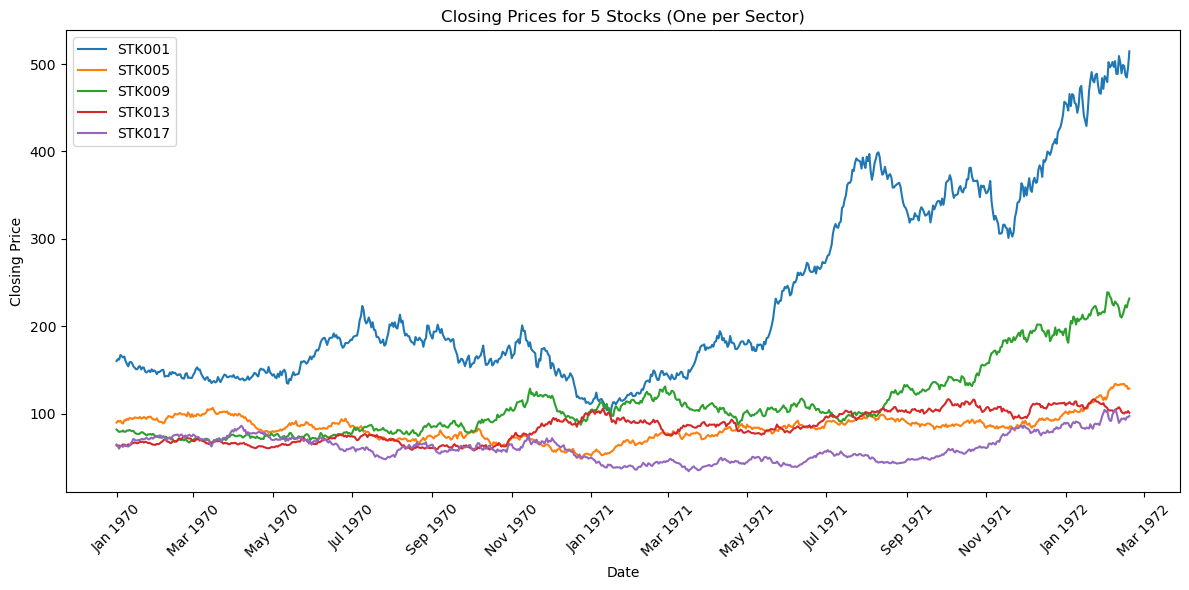

In [44]:
# Column names (as confirmed)
sector_col = "sector"
date_col = "date"
close_col = "close"

# Pick 5 sectors and 1 stock from each
five_sectors = merged_df[sector_col].dropna().unique()[:5]
sample_tickers = []

for sector in five_sectors:
    ticker = merged_df[merged_df[sector_col] == sector]["ticker"].iloc[0]
    sample_tickers.append(ticker)

# Filter merged_df to selected tickers only
plot_df = merged_df[merged_df["ticker"].isin(sample_tickers)]

# Plot
plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    sub = plot_df[plot_df["ticker"] == ticker]
    plt.plot(sub[date_col], sub[close_col], label=ticker)

plt.title("Closing Prices for 5 Stocks (One per Sector)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Jan 2024 style
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
Stock_Price_With_Indicators_Data=pd.read_csv('../Data/stock_prices_with_indicators.csv')
Stock_Price_With_Indicators_Data.head()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,...,2.88,2.880,962644.00,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,...,5.39,4.135,1137664.50,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,...,1.57,3.280,1241502.00,1.167277,NaN,NaN,0.002251,0.012463,-0.012301,Sideways
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,...,6.12,3.990,1314834.75,1.167320,NaN,NaN,0.026039,0.018138,-0.061950,Downtrend
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,...,4.08,4.008,1221520.00,0.694431,NaN,NaN,0.013953,0.018663,-0.070196,Downtrend


C:\Users\ephra\AppData\Local\Temp\ipykernel_12404\1175506704.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  change = (prices[i] - window_prices[0]) / window_prices[0]
C:\Users\ephra\AppData\Local\Temp\ipykernel_12404\1175506704.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color=colors[i],


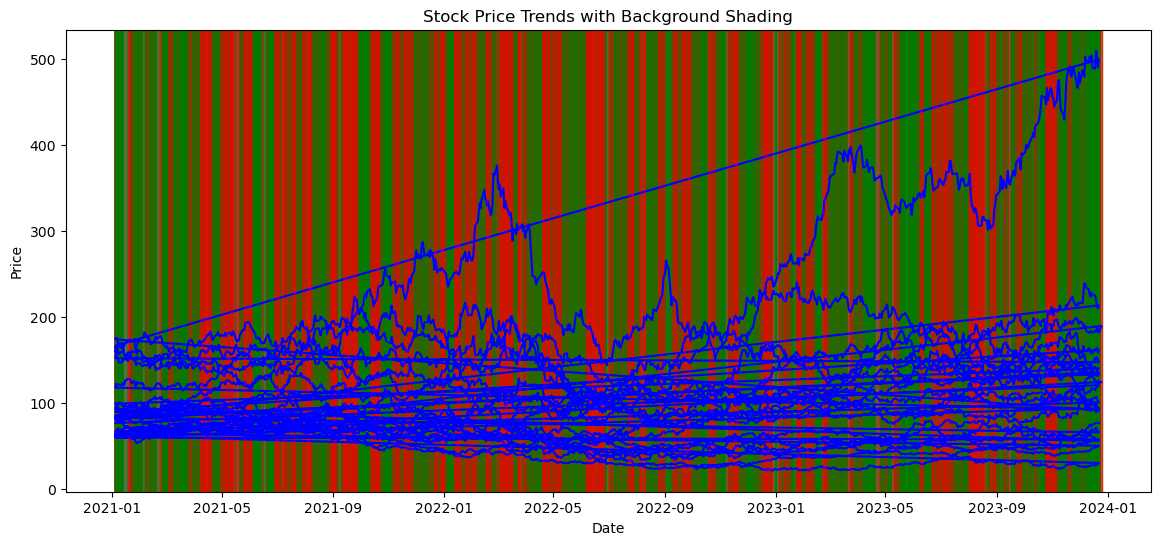

In [46]:
# Make sure the date column is datetime
Stock_Price_With_Indicators_Data['date'] = pd.to_datetime(Stock_Price_With_Indicators_Data['date'])
Stock_Price_With_Indicators_Data.set_index('date', inplace=True)

# Use closing price for trend detection
prices = Stock_Price_With_Indicators_Data['close']

# Define trend detection logic
def detect_trends(prices, window=5, threshold=0.002):
    """
    Detect uptrends, downtrends, and sideways movements.
    - window: number of periods to calculate rolling trend
    - threshold: minimum relative change to consider a trend
    """
    trend = []
    for i in range(len(prices)):
        if i < window:
            trend.append('sideways')
            continue
        window_prices = prices[i-window:i]
        change = (prices[i] - window_prices[0]) / window_prices[0]
        if change > threshold:
            trend.append('uptrend')
        elif change < -threshold:
            trend.append('downtrend')
        else:
            trend.append('sideways')
    return trend

Stock_Price_With_Indicators_Data['Trend'] = detect_trends(prices)

# Assign colors for plotting
color_map = {'uptrend':'green', 'downtrend':'red', 'sideways':'gray'}
colors = Stock_Price_With_Indicators_Data['Trend'].map(color_map)

# Plot
plt.figure(figsize=(14,6))
plt.plot(Stock_Price_With_Indicators_Data.index, Stock_Price_With_Indicators_Data['close'], color='blue', label='Close Price')

# Highlight trends
for i in range(1, len(Stock_Price_With_Indicators_Data)):
    plt.axvspan(
        Stock_Price_With_Indicators_Data.index[i-1],
        Stock_Price_With_Indicators_Data.index[i],
        color=colors[i],
        alpha=0.3
    )
plt.title('Stock Price Trends with Background Shading')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

#### Basic Statistics

In [47]:
Stock_Price_With_Indicators_Data= pd.read_csv('../Data/stock_prices_with_indicators.csv')
returns=Stock_Price_With_Indicators_Data['future_return_5d']

mean_val=returns.mean()
median_val=returns.median()
std_val=returns.std()

print("Mean:",mean_val)
print("Median:",median_val)
print("Standard Deviation:",std_val)

Mean: 0.0024658553556976006
Median: 0.00206073244693975
Standard Deviation: 0.05349068834420799


### Sector Comparison

In [48]:
## Creating new dataframe for sector analysis
merged_sector_analysis_df=pd.merge(Stock_Price_With_Indicators_Data,Company_Info, on='ticker', how='inner')

merged_sector_analysis_df.tail()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label,company_name,sector,ipo_date
15497,STK020,2023-12-18,76.16,77.62,75.43,76.39,1029767.0,76.39,67.238,58.9968,...,0.840504,0.106620,0.344658,0.294816,0.024476,-0.046865,Downtrend,RenewTech,Energy,2017-09-11
15498,STK020,2023-12-19,76.93,78.72,75.06,76.97,1031912.0,76.97,68.222,59.4778,...,0.853584,0.170468,0.343515,0.294096,0.024489,0.010913,Sideways,RenewTech,Energy,2017-09-11
15499,STK020,2023-12-20,77.89,77.89,76.83,77.24,1057795.0,77.24,69.164,59.9724,...,0.884184,0.151118,0.322603,0.287926,0.024602,-0.004531,Sideways,RenewTech,Energy,2017-09-11
15500,STK020,2023-12-21,76.88,78.90,74.48,76.74,1072067.0,76.74,70.048,60.4466,...,0.890195,0.142474,0.299357,0.269550,0.025036,-0.021371,Downtrend,RenewTech,Energy,2017-09-11
15501,STK020,2023-12-22,78.10,78.10,75.98,76.81,1259507.0,76.81,70.747,60.9676,...,1.045070,0.097442,0.222505,0.259849,0.022163,-0.011457,Sideways,RenewTech,Energy,2017-09-11


In [49]:
## Average Return by Sector

merged_sector_analysis_df.groupby('sector')['future_return_5d'].mean().sort_values(ascending=False)

sector
Finance       0.003610
Consumer      0.002566
Technology    0.002308
Healthcare    0.002202
Energy        0.001642
Name: future_return_5d, dtype: float64

In [50]:
## Comparison of volatility across sectors

merged_sector_analysis_df=pd.merge(Stock_Price_With_Indicators_Data,Company_Info, on='ticker', how='inner')
merged_sector_analysis_df['daily_return'] = merged_sector_analysis_df.groupby('ticker')['close'].pct_change()
volatility = merged_sector_analysis_df.groupby('sector')['daily_return'].std().reset_index().rename(columns={'daily_return': 'volatility'})
volatility.sort_values('volatility', ascending=False)

,sector,volatility
1,Energy,0.031006
4,Technology,0.025141
2,Finance,0.022866
3,Healthcare,0.020734
0,Consumer,0.018532


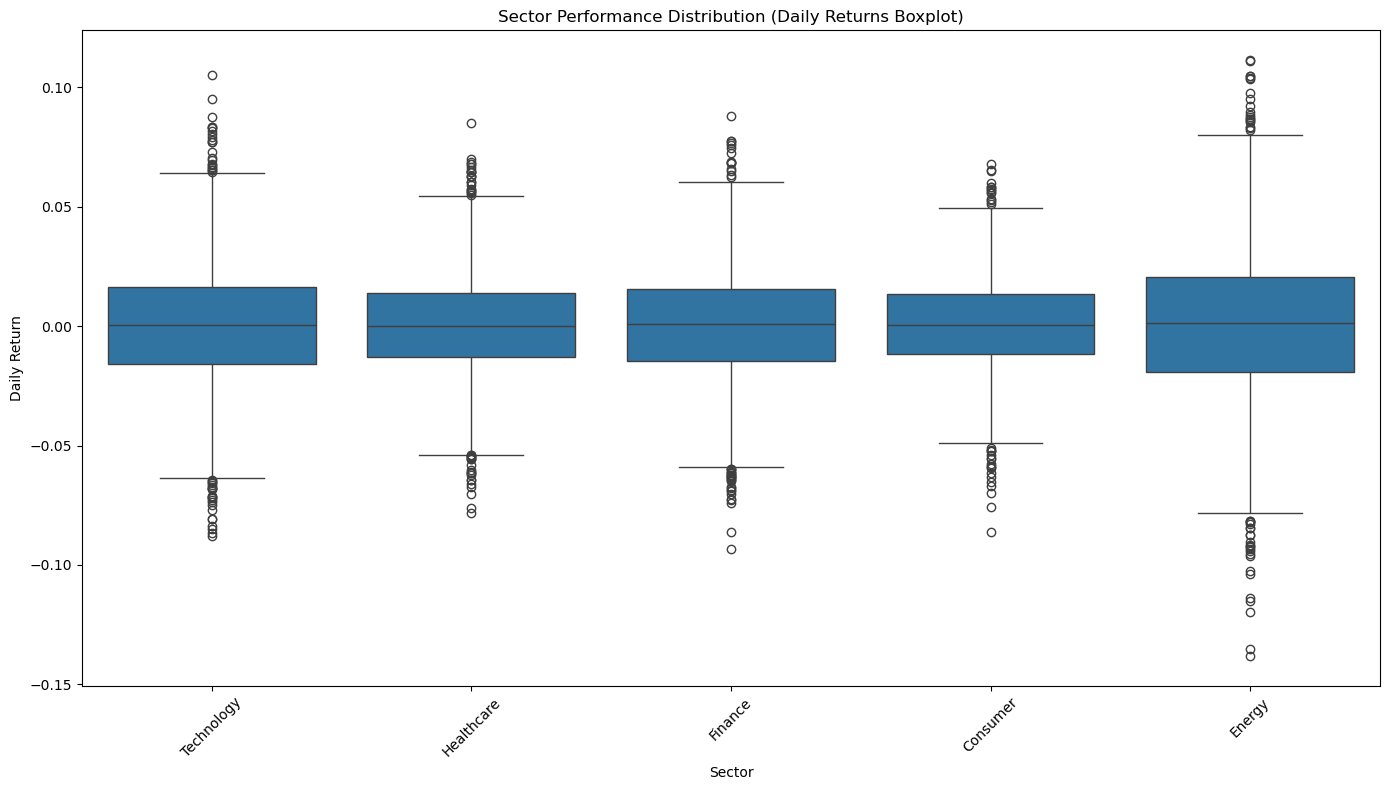

In [51]:
## Visualize sector performance with box plots

merged_sector_analysis_df=pd.merge(Stock_Price_With_Indicators_Data,Company_Info, on='ticker', how='inner')

# Ensure dataset is sorted by ticker + date
merged_sector_analysis_df['date'] = pd.to_datetime(merged_sector_analysis_df['date'])
merged_sector_analysis_df = merged_sector_analysis_df.sort_values(['ticker', 'date'])

# Compute daily returns if missing
if 'daily_return' not in merged_sector_analysis_df.columns:
    merged_sector_analysis_df['daily_return'] = merged_sector_analysis_df.groupby("ticker")['close'].pct_change()

# Create boxplot by sector
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=merged_sector_analysis_df,
    x='sector',
    y='daily_return'
)
plt.xticks(rotation=45)
plt.title("Sector Performance Distribution (Daily Returns Boxplot)")
plt.xlabel("Sector")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.show()

##### Notes: There are huge outliers across sectore. The energy sector has the tallest box and this indicates higher volatility while the consumer sector has the least volatility. The energy and the technology sectors has the longer whiskers in plot suggesting they are both the sectors with the greater risk spread. However, median line accross sectors are almost the same.

In [52]:
## Rank sectors by risk-adjusted return (Sharpe-style metric

sector_stats = merged_sector_analysis_df.groupby("sector").agg(
    avg_return=("daily_return", "mean"),
    volatility=("daily_return", "std")
)
sector_stats["risk_adjusted_return"] = sector_stats["avg_return"] / sector_stats["volatility"]
print(sector_stats.sort_values("risk_adjusted_return", ascending=False))

            avg_return  volatility  risk_adjusted_return
sector                                                  
Finance       0.000732    0.022866              0.032015
Consumer      0.000571    0.018532              0.030785
Healthcare    0.000480    0.020734              0.023150
Technology    0.000457    0.025141              0.018169
Energy        0.000371    0.031006              0.011959


### Volume Analysis

#### volume patterns over time


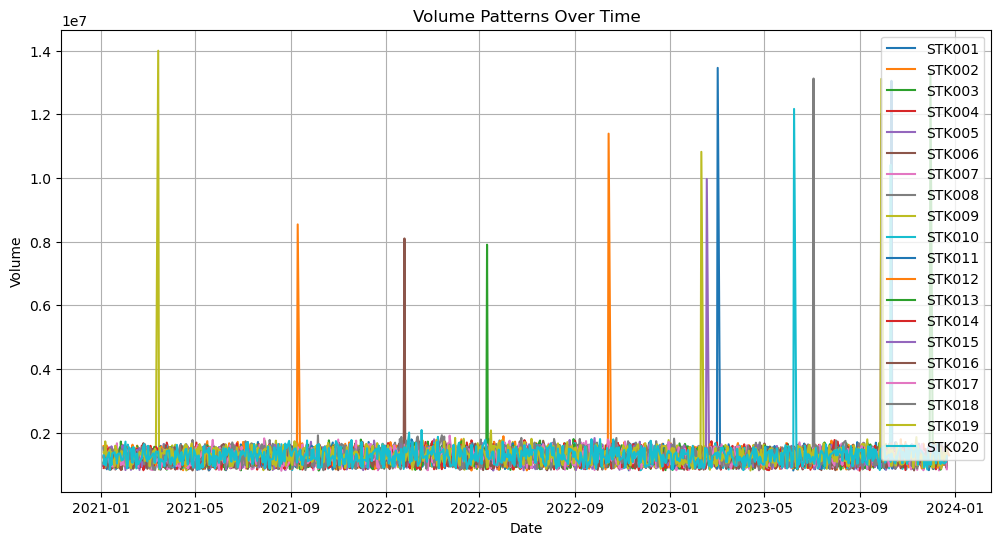

In [53]:
# Ensure the date column is datetime
merged_sector_analysis_df['date'] = pd.to_datetime(merged_sector_analysis_df['date'])

plt.figure(figsize=(12, 6))

for ticker in merged_sector_analysis_df['ticker'].unique():
    subset = merged_sector_analysis_df[merged_sector_analysis_df['ticker'] == ticker]
    plt.plot(subset['date'], subset['volume'], label=ticker)

plt.title("Volume Patterns Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

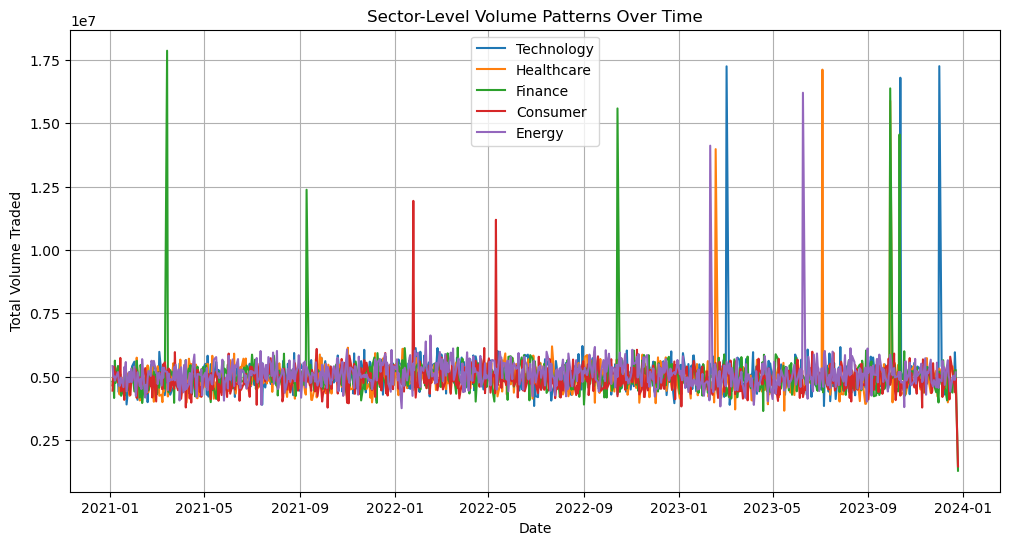

In [54]:
plt.figure(figsize=(12, 6))

for sector in merged_sector_analysis_df['sector'].unique():
    sector_data = merged_sector_analysis_df.groupby(['date','sector'])['volume'].sum().reset_index()
    subset = sector_data[sector_data['sector'] == sector]
    plt.plot(subset['date'], subset['volume'], label=sector)

plt.title("Sector-Level Volume Patterns Over Time")
plt.xlabel("Date")
plt.ylabel("Total Volume Traded")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# merged_sector_analysis_df is already merged
df = merged_sector_analysis_df.copy()

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by ticker & date
df = df.sort_values(['ticker', 'date'])

# --------------------------------------------
# 1️⃣ Calculate Price Change (Percentage)
# --------------------------------------------
df['price_change_pct'] = (df['close'] - df['close'].shift(1)) / df['close'].shift(1) * 100

# --------------------------------------------
# 2️⃣ Calculate Volume Threshold For "High Volume" Days
#    Criterion: Volume > 90th percentile (per stock)
# --------------------------------------------
df['high_volume'] = df.groupby('ticker')['volume'].transform(
    lambda x: x > x.quantile(0.90)
)

# --------------------------------------------
# 3️⃣ Filter high-volume days
# --------------------------------------------
high_volume_days = df[df['high_volume'] == True]

# --------------------------------------------
# 4️⃣ Summary Statistics: Relationship to Price Movement
# --------------------------------------------
relationship_summary = high_volume_days.groupby('ticker').agg(
    avg_price_change_on_high_volume = ('price_change_pct', 'mean'),
    positive_days_pct = ('price_change_pct', lambda x: (x > 0).mean() * 100),
    count_high_volume_days = ('date', 'count')
).reset_index()

print("📌 Summary: Price Behaviour on High-Volume Days")
print(relationship_summary.head())

📌 Summary: Price Behaviour on High-Volume Days
   ticker  avg_price_change_on_high_volume  positive_days_pct  \
0  STK001                         0.147632          48.717949   
1  STK002                        -0.572013          46.153846   
2  STK003                        -0.160861          48.717949   
3  STK004                         0.273549          55.128205   
4  STK005                         0.248620          50.000000   

   count_high_volume_days  
0                      78  
1                      78  
2                      78  
3                      78  
4                      78  


#### Insights Per-Ticker

#####  avg_price_change_on_high_volume speaks to the average % change in price after high volume days while positive_days_pct indicate % of high-volume days that had a price increase and count_high_volume_days refers to the number of detected high-volume days. 

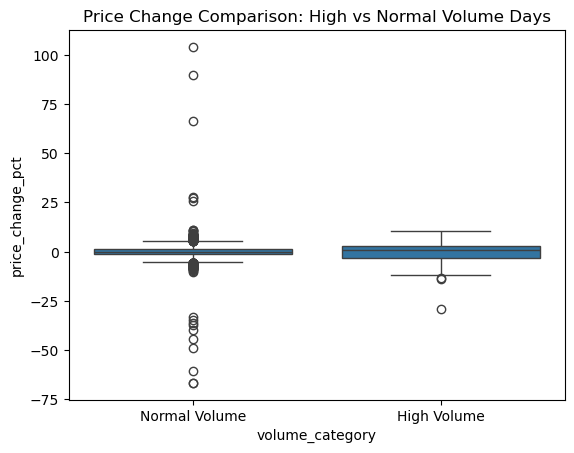

In [56]:
df['volume_category'] = np.where(df['high_volume'], "High Volume", "Normal Volume")

sns.boxplot(data=df, x='volume_category', y='price_change_pct')
plt.title("Price Change Comparison: High vs Normal Volume Days")
plt.show()

In [57]:
df = merged_sector_analysis_df.copy()

# Ensure date is datetime and sorted
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date'])

# --------------------------------------------
# 1️⃣ Calculate daily % price change
# --------------------------------------------
df['price_change_pct'] = (df['close'] - df['close'].shift(1)) / df['close'].shift(1) * 100

# --------------------------------------------
# 2️⃣ Compute correlation between volume and price movement for each ticker
# --------------------------------------------
correlation_results = (
    df.groupby('ticker')
      .apply(lambda x: x[['volume', 'price_change_pct']].corr().iloc[0, 1])
      .reset_index(name='volume_price_corr')
)

print("📌 Correlation between Volume and Price % Change (per ticker):")
print(correlation_results.head())

📌 Correlation between Volume and Price % Change (per ticker):
   ticker  volume_price_corr
0  STK001          -0.026284
1  STK002          -0.032013
2  STK003          -0.018339
3  STK004           0.032176
4  STK005          -0.035350


C:\Users\ephra\AppData\Local\Temp\ipykernel_12404\1380990168.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[['volume', 'price_change_pct']].corr().iloc[0, 1])


In [58]:
sector_correlation = df.groupby(['sector', 'ticker']).apply(
    lambda x: x[['volume', 'price_change_pct']].corr().iloc[0, 1]
).reset_index(name='corr')

sector_summary = sector_correlation.groupby('sector')['corr'].mean().reset_index()
print("📌 Average correlation per sector")
print(sector_summary)

📌 Average correlation per sector
       sector      corr
0    Consumer  0.008288
1      Energy -0.040482
2     Finance -0.000223
3  Healthcare  0.007792
4  Technology -0.011115


C:\Users\ephra\AppData\Local\Temp\ipykernel_12404\1097230264.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sector_correlation = df.groupby(['sector', 'ticker']).apply(


In [59]:
## Handling Outliers

In [60]:
## Identify Outliers Using IQR Method

In [61]:
numeric_df= merged_sector_analysis_df.select_dtypes(include='number')
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3-Q1

outliers = numeric_df[
    (numeric_df<(Q1-1.5*IQR))|
    (numeric_df>(Q3+1.5*IQR))
]
print(outliers)

       open  high  low  close  volume  adjusted_close  sma_20  sma_50  \
0       NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
1       NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
2       NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
3       NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
4       NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
...     ...   ...  ...    ...     ...             ...     ...     ...   
15497   NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
15498   NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
15499   NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
15500   NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   
15501   NaN   NaN  NaN    NaN     NaN             NaN     NaN     NaN   

       sma_200  ema_12  ...  true_range  atr_14  volume_sma_20  volume_ratio  \
0          NaN     NaN  ...         NaN    

In [62]:
## Remove Outliers

numeric_df= merged_sector_analysis_df.select_dtypes(include='number')
# Compute interquartile ranges for Q1 and Q3 and produce the difference
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3-Q1
# Calculate acceptable value limits
lower_bound =Q1-1.5*IQR
upper_bound =Q3+1.5*IQR
# Filter out rows with ANY outlier

numeric_df_no_outliers = numeric_df[
    (
        (numeric_df< lower_bound)|
        (numeric_df> upper_bound)
        ).any(axis=1)
 ]

numeric_df_no_outliers.head()


,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,ema_12,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,daily_return
0,158.09,160.97,158.09,160.11,962644.0,160.11,160.110,160.110000,160.110000,160.110000,...,2.88,2.880000,962644.00,1.000000,NaN,NaN,0.000000,NaN,0.026357,NaN
1,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235,161.235000,161.235000,160.456154,...,5.39,4.135000,1137664.50,1.153842,NaN,NaN,0.006977,NaN,0.018169,0.014053
37,151.65,151.65,140.20,142.41,1632984.0,142.41,148.958,153.514211,153.514211,148.083765,...,11.45,5.227143,1247233.30,1.309285,-0.055073,-0.072489,-0.072333,0.018044,0.017625,-0.051296
86,142.35,144.95,138.27,141.68,828200.0,141.68,139.454,142.677000,147.413563,141.021446,...,6.68,4.779286,1086614.20,0.762184,0.044453,-0.009923,-0.006988,0.018795,-0.003176,-0.000494
89,147.67,147.67,141.16,142.22,861570.0,142.22,139.828,142.661200,147.251556,141.616051,...,6.51,5.082143,1092331.75,0.788744,0.025970,0.008796,-0.003093,0.017711,-0.015750,-0.004201


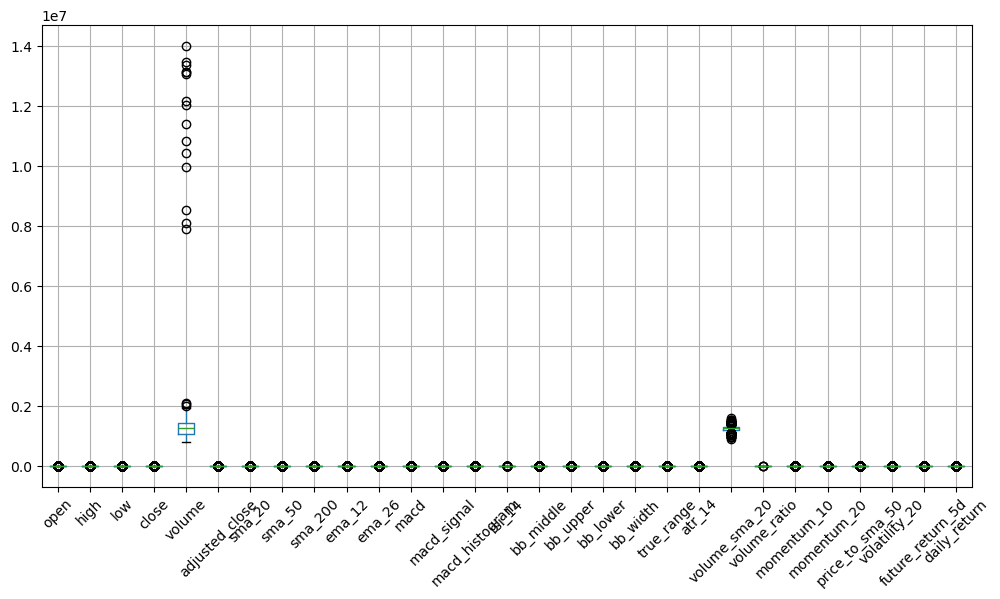

In [63]:
numeric_df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

## Technical Indicator Exploration

##### Visualization of RSI patterns and identification of overbought/oversold conditions

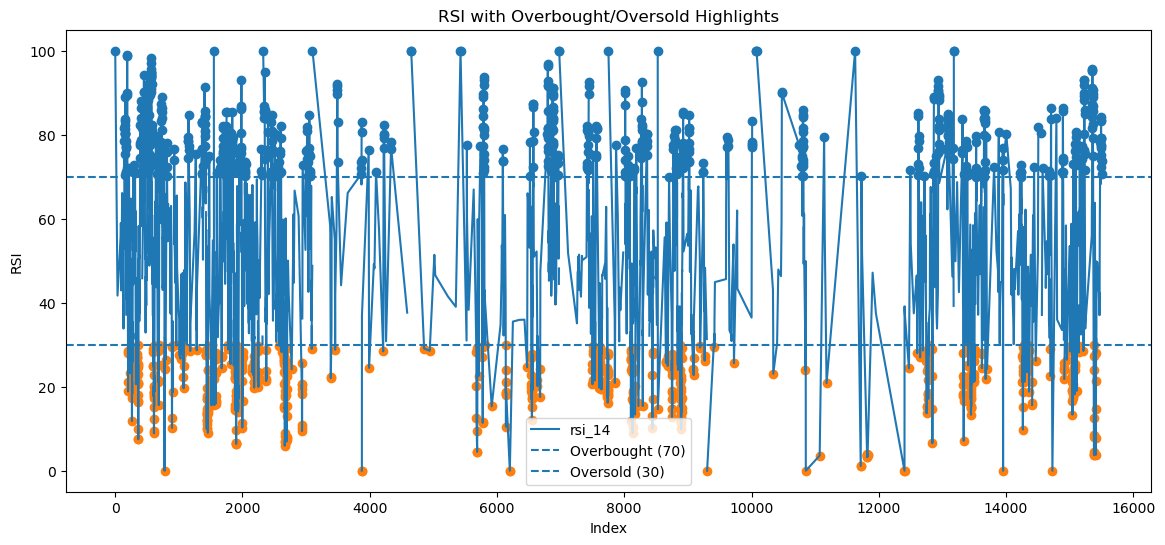

In [64]:
plt.figure(figsize=(14,6))
plt.plot(numeric_df_no_outliers['rsi_14'], label='rsi_14')

# Threshold lines
plt.axhline(70, linestyle='--', label='Overbought (70)')
plt.axhline(30, linestyle='--', label='Oversold (30)')

# Highlight overbought points
overbought = numeric_df_no_outliers[numeric_df_no_outliers['rsi_14'] > 70]
plt.scatter(overbought.index, overbought['rsi_14'])

# Highlight oversold points
oversold = numeric_df_no_outliers[numeric_df_no_outliers['rsi_14'] < 30]
plt.scatter(oversold.index, oversold['rsi_14'])

plt.title("RSI with Overbought/Oversold Highlights")
plt.xlabel("Index")
plt.ylabel("RSI")
plt.legend()
plt.show()

#### Plotting MACD crossovers and their relationship to price trends

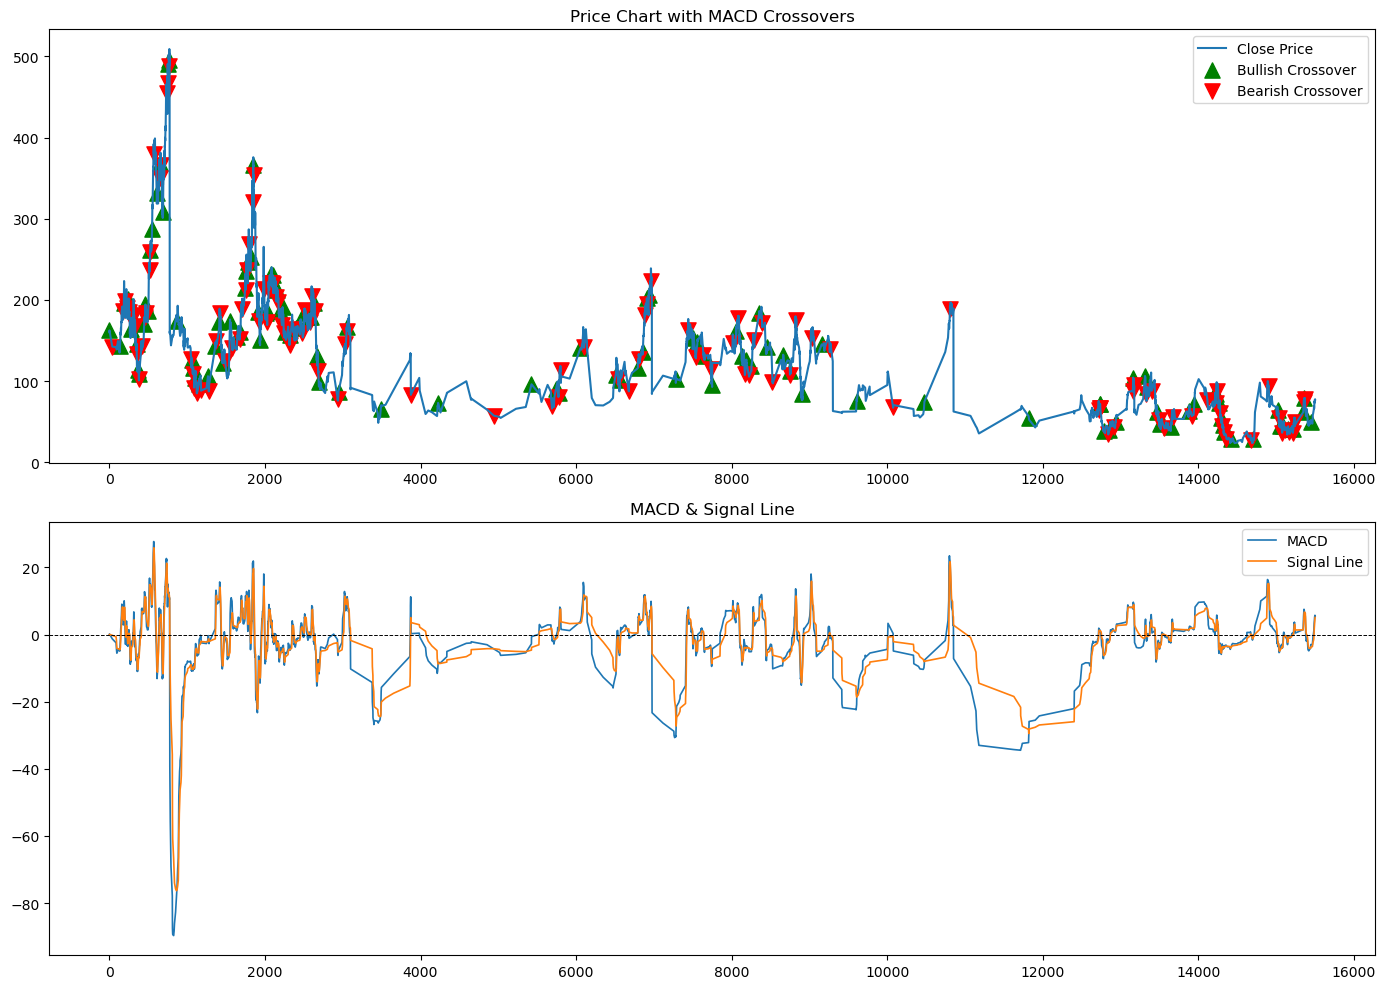

In [65]:
df = numeric_df_no_outliers.copy()

# --- 1. Compute MACD ---
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# --- 2. Identify MACD Crossovers ---
df['prev_macd'] = df['MACD'].shift(1)
df['prev_signal'] = df['Signal'].shift(1)

# Bullish crossover: MACD crosses above Signal
df['Buy_Signal'] = ((df['MACD'] > df['Signal']) & 
                    (df['prev_macd'] <= df['prev_signal']))

# Bearish crossover: MACD crosses below Signal
df['Sell_Signal'] = ((df['MACD'] < df['Signal']) & 
                     (df['prev_macd'] >= df['prev_signal']))

# --- 3. Plot Price + Buy/Sell markers ---
plt.figure(figsize=(14,10))

# PRICE CHART
plt.subplot(2, 1, 1)
plt.plot(df['close'], label='Close Price')

plt.scatter(df.index[df['Buy_Signal']], 
            df['close'][df['Buy_Signal']], 
            marker='^', color='green', s=120, label='Bullish Crossover')

plt.scatter(df.index[df['Sell_Signal']], 
            df['close'][df['Sell_Signal']], 
            marker='v', color='red', s=120, label='Bearish Crossover')

plt.title("Price Chart with MACD Crossovers")
plt.legend()

# --- 4. MACD SUBPLOT ---
plt.subplot(2, 1, 2)
plt.plot(df['MACD'], label='MACD', linewidth=1.2)
plt.plot(df['Signal'], label='Signal Line', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)

plt.title("MACD & Signal Line")
plt.legend()

plt.tight_layout()
plt.show()


#### Visualization Interpretation
##### The Bullish MACD crossover (green ▲) shows MACD rises above the Signal line which suggests upward momentum.Conversely, the Bearish MACD crossover (red ▼) shows MACD drops below the Signal line which suggests downward momentum. 

#### Relationship to price trends: The goal of combining both plots makes trend-momentum relationships easy to see as Price often rises shortly after bullish crossovers and price declines after bearish crossovers.

#### Examine Bollinger Band patterns

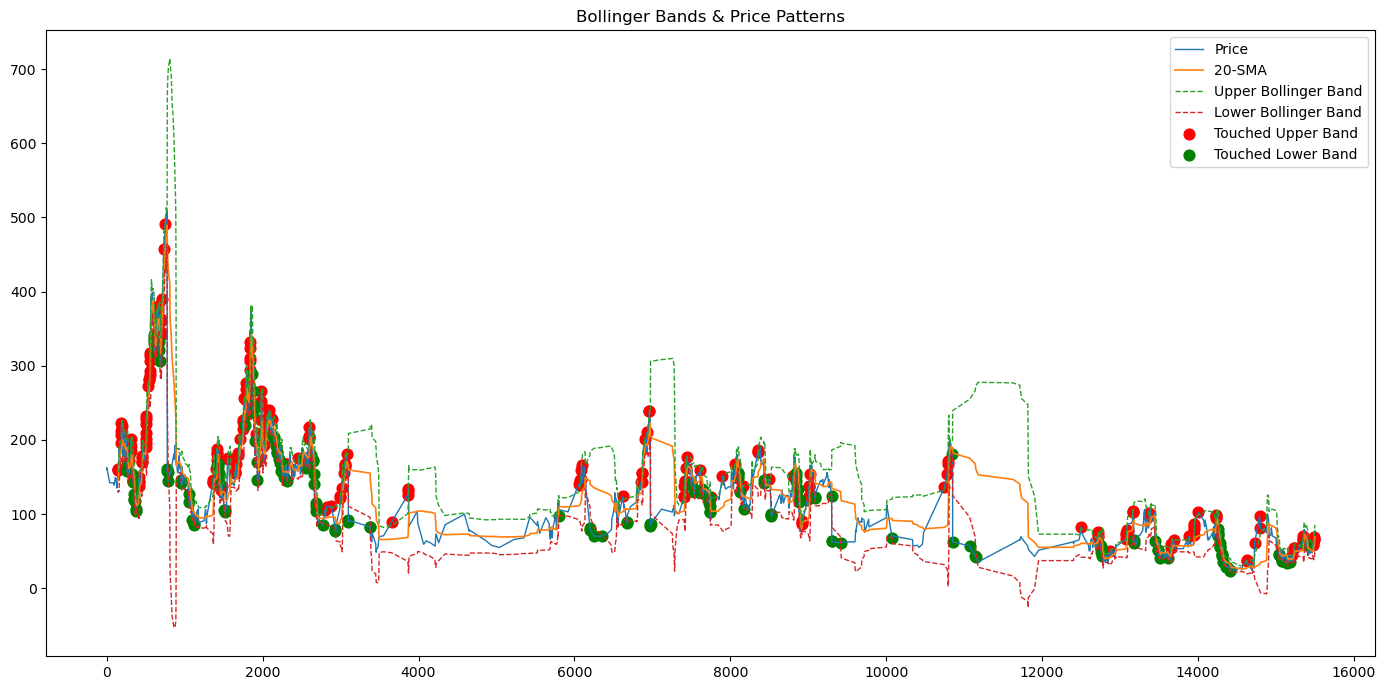

In [66]:
df = numeric_df_no_outliers.copy()

# Ensure your price column matches
price_col = 'close'

# --- Compute Bollinger Bands ---
df['SMA20'] = df[price_col].rolling(window=20).mean()
df['STD20'] = df[price_col].rolling(window=20).std()

df['Upper_Band'] = df['SMA20'] + (2 * df['STD20'])
df['Lower_Band'] = df['SMA20'] - (2 * df['STD20'])

# Identify common Bollinger Band signals
df['Touch_Upper'] = df[price_col] >= df['Upper_Band']
df['Touch_Lower'] = df[price_col] <= df['Lower_Band']
df['Squeeze'] = (df['Upper_Band'] - df['Lower_Band']) < \
                (df['Upper_Band'] - df['Lower_Band']).rolling(window=100).mean()

# --- Plotting ---
plt.figure(figsize=(14,7))

plt.plot(df[price_col], label='Price', linewidth=1)
plt.plot(df['SMA20'], label='20-SMA', linewidth=1.2)
plt.plot(df['Upper_Band'], label='Upper Bollinger Band', linewidth=1, linestyle='--')
plt.plot(df['Lower_Band'], label='Lower Bollinger Band', linewidth=1, linestyle='--')

# Highlight touches
plt.scatter(df.index[df['Touch_Upper']], 
            df[price_col][df['Touch_Upper']], 
            color='red', marker='o', s=60, label='Touched Upper Band')

plt.scatter(df.index[df['Touch_Lower']], 
            df[price_col][df['Touch_Lower']], 
            color='green', marker='o', s=60, label='Touched Lower Band')

plt.title("Bollinger Bands & Price Patterns")
plt.legend()
plt.tight_layout()
plt.show()

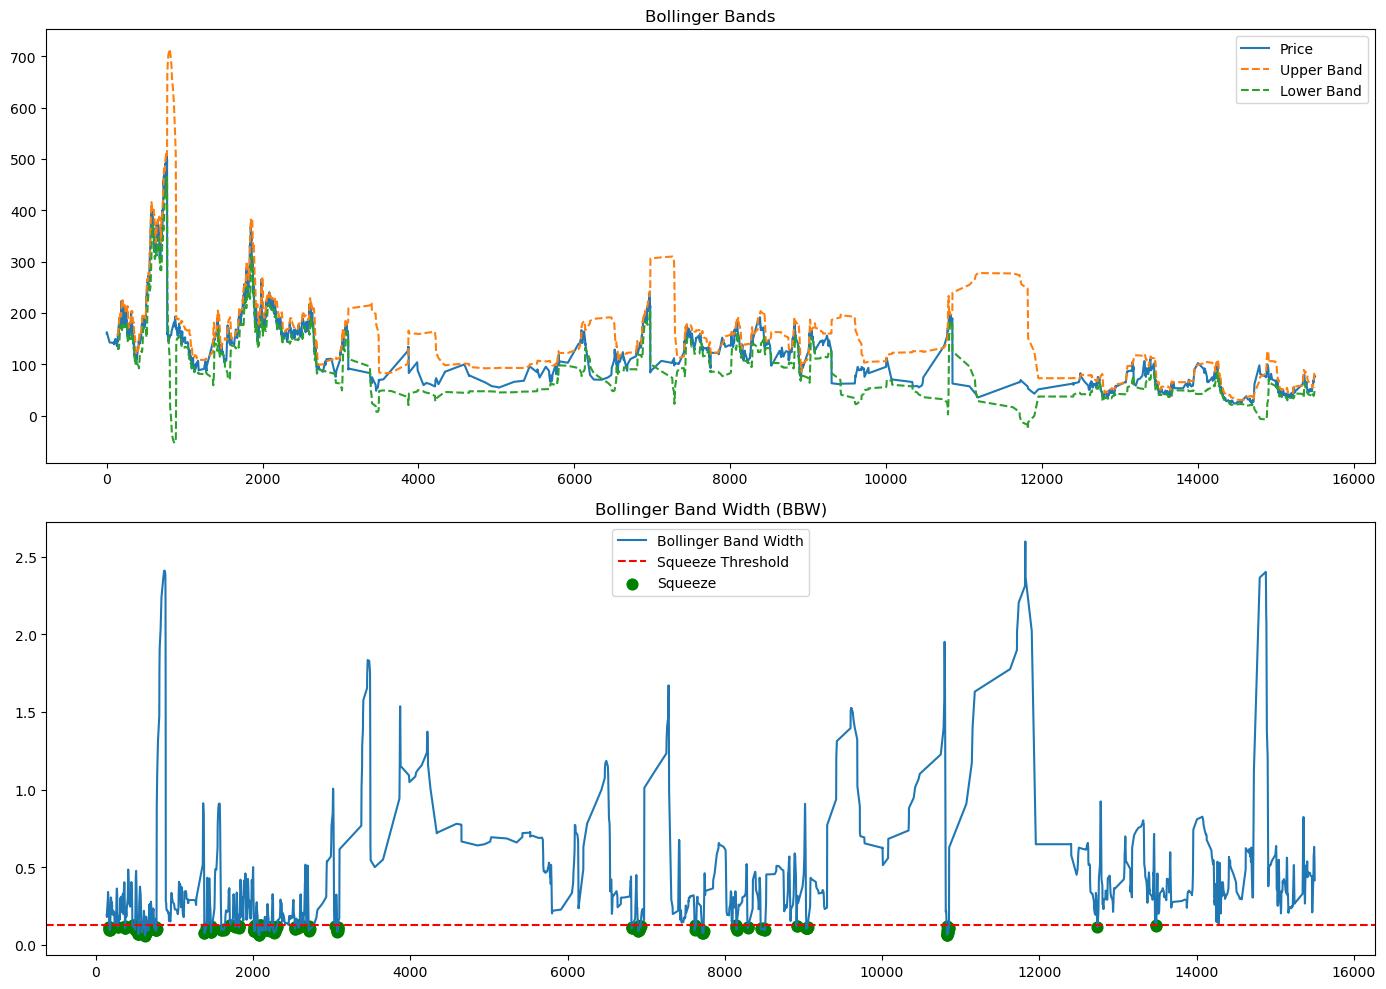

In [67]:
df = numeric_df_no_outliers.copy()
price_col = 'close'

# --- Compute Bollinger Bands ---
df['SMA20'] = df[price_col].rolling(20).mean()
df['STD20'] = df[price_col].rolling(20).std()

df['Upper_Band'] = df['SMA20'] + 2 * df['STD20']
df['Lower_Band'] = df['SMA20'] - 2 * df['STD20']

# --- Compute Bollinger Band Width ---
df['BBW'] = (df['Upper_Band'] - df['Lower_Band']) / df['SMA20']

# Optional: identify squeezes (lowest 10% BBW)
threshold = df['BBW'].quantile(0.10)
df['Squeeze'] = df['BBW'] <= threshold

# --- Plot Price + BBW ---
plt.figure(figsize=(14,10))

# Price with Bollinger Bands
plt.subplot(2, 1, 1)
plt.plot(df[price_col], label='Price')
plt.plot(df['Upper_Band'], label='Upper Band', linestyle='--')
plt.plot(df['Lower_Band'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()

# BBW plot
plt.subplot(2, 1, 2)
plt.plot(df['BBW'], label='Bollinger Band Width')
plt.axhline(threshold, color='red', linestyle='--', label='Squeeze Threshold')

# Highlight squeeze zones
plt.scatter(df.index[df['Squeeze']], 
            df['BBW'][df['Squeeze']], 
            color='green', s=60, label='Squeeze')

plt.title("Bollinger Band Width (BBW)")
plt.legend()

plt.tight_layout()
plt.show()

### Correlation Analysis

In [68]:
numeric_df_no_outliers_filled = numeric_df_no_outliers.fillna(numeric_df_no_outliers.mean())

In [69]:
print(numeric_df_no_outliers_filled.columns)

Index(['open', 'high', 'low', 'close', 'volume', 'adjusted_close', 'sma_20',
       'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal',
       'macd_histogram', 'rsi_14', 'bb_middle', 'bb_upper', 'bb_lower',
       'bb_width', 'true_range', 'atr_14', 'volume_sma_20', 'volume_ratio',
       'momentum_10', 'momentum_20', 'price_to_sma_50', 'volatility_20',
       'future_return_5d', 'daily_return'],
      dtype='object')


#### Correlation heatmap of all features

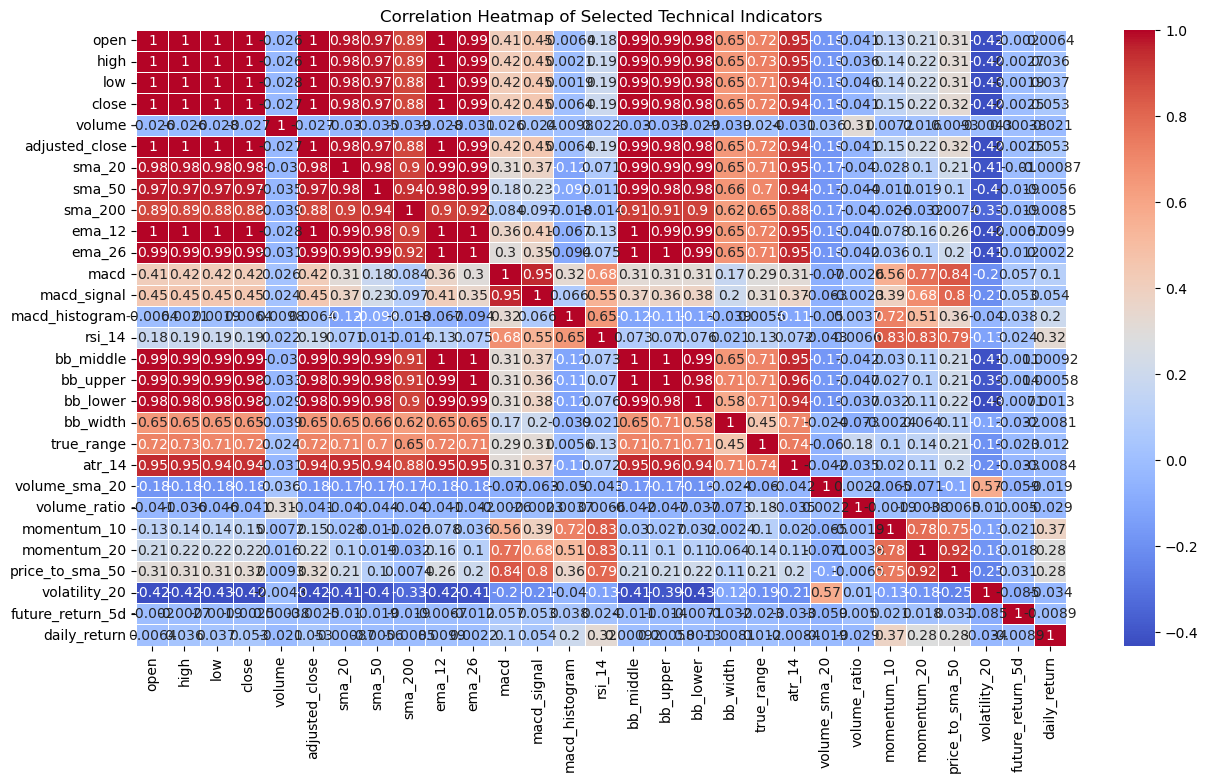

In [70]:


# Select only the chosen features that exist in the dataframe
selected_df = numeric_df_no_outliers_filled

# Compute correlation matrix
corr_matrix = selected_df.corr()

# Plot heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Technical Indicators")
plt.show()

#### Highly correlated features (potential multicollinearity)

In [71]:
df = numeric_df_no_outliers_filled.copy()

corr_matrix = df.corr()
corr_matrix

threshold = 0.85  # choose your own threshold

# Create matrix of correlations above threshold (excluding diagonal)
high_corr_pairs = (
    corr_matrix.mask(np.tril(np.ones(corr_matrix.shape)).astype(bool))  # remove duplicates + diagonal
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Filter only strong correlations
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() >= threshold]

high_corr_pairs

,Feature_1,Feature_2,Correlation
0,open,high,0.999053
1,open,low,0.999043
2,open,close,0.998181
4,open,adjusted_close,0.998181
5,open,sma_20,0.981368
...,...,...,...
319,bb_middle,atr_14,0.953904
328,bb_upper,bb_lower,0.983958
331,bb_upper,atr_14,0.958686
342,bb_lower,atr_14,0.936571


In [72]:
#### Convert date object to datetime

Stock_Price_With_Indicators_Data['date'] = pd.to_datetime(
    Stock_Price_With_Indicators_Data['date'], 
    errors='coerce')

#### Correlation heatmap of selected features


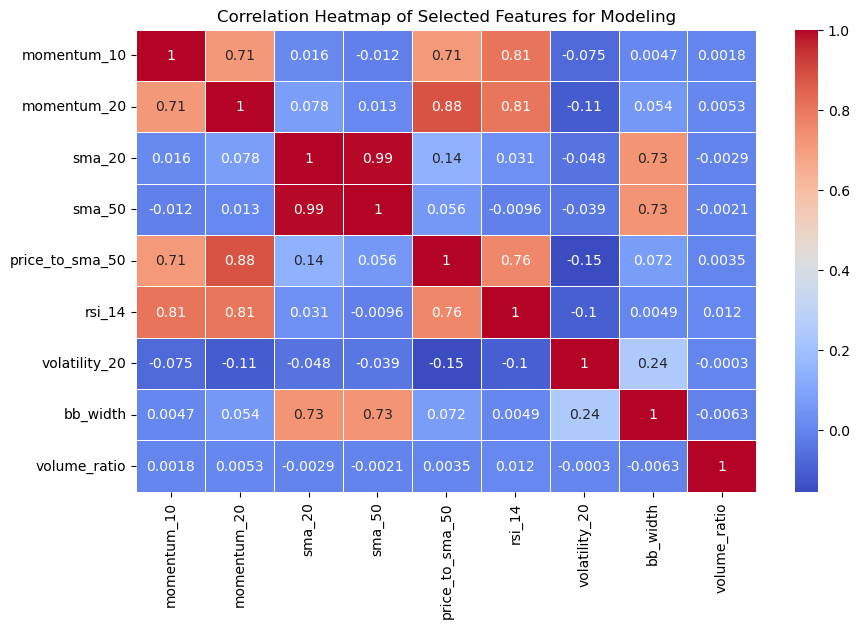

In [73]:
features = ['momentum_10','momentum_20','sma_20','sma_50','price_to_sma_50','rsi_14','volatility_20','bb_width','volume_ratio']

# Select only the chosen features that exist in the dataframe
selected_df = Stock_Price_With_Indicators_Data[features]

# Compute correlation matrix
corr_matrix = selected_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Features for Modeling")
plt.show()

In [74]:
Stock_Price_With_Indicators_Data['trend_label'].isna().sum()

0

#### Train-Test Split

In [75]:
# Sort by date (earliest to latest)
Stock_Price_With_Indicators_Data = Stock_Price_With_Indicators_Data.sort_values('date')

# Determine split index
split_index = int(len(Stock_Price_With_Indicators_Data) * 0.7)

# Create train and test sets
train_df = Stock_Price_With_Indicators_Data.iloc[:split_index]
test_df  = Stock_Price_With_Indicators_Data.iloc[split_index:]

train_df.to_csv('modeling_dataset_train.csv', index=False)
test_df.to_csv('modeling_dataset_test.csv', index=False)

#### Checking split outcome to ensure it meets criteria

In [76]:
print("Train set length:", len(train_df))
print("Test set length:", len(test_df))
print("Train start/end:", train_df['date'].min(), train_df['date'].max())
print("Test start/end:", test_df['date'].min(), test_df['date'].max())

Train set length: 10851
Test set length: 4651
Train start/end: 2021-01-04 00:00:00 2023-02-01 00:00:00
Test start/end: 2023-02-01 00:00:00 2023-12-25 00:00:00


#### Verify if there is missing values in model dataset

In [77]:
print("\nMissing values in train:", train_df["trend_label"].isna().sum())
print("Missing values in test :", test_df["trend_label"].isna().sum())


Missing values in train: 0
Missing values in test : 0


In [78]:
print("\nTrain trend_label distribution:")
print(train_df["trend_label"].value_counts(dropna=False))

print("\nTest trend_label distribution:")
print(test_df["trend_label"].value_counts(dropna=False))


Train trend_label distribution:
trend_label
Uptrend      3820
Downtrend    3670
Sideways     3361
Name: count, dtype: int64

Test trend_label distribution:
trend_label
Uptrend      1712
Sideways     1583
Downtrend    1356
Name: count, dtype: int64
